In [1]:
import pandas as pd
import numpy as np
import os
#import matplotlib.pyplot as plt

In [2]:
os.getcwd()

'/mnt/c/Users/ansel/AppData/Local/Programs/Microsoft VS Code'

In [3]:
current_path='/mnt/d/GitHub/WQU-Capstone/notebooks/CAE_9-6-25' 
os.chdir(current_path)

os.getcwd()

'/mnt/d/GitHub/WQU-Capstone/notebooks/CAE_9-6-25'

## Import data

In [4]:
pkl_data = f"{current_path}/etf_data_with_indicators.pkl"
index_dict = pd.read_pickle(pkl_data)
index_dict

{'ARKK':                             adjClose    adjHigh     adjLow    adjOpen  \
 date                                                                    
 2018-01-02 00:00:00+00:00  36.133634  36.143000  34.885160  34.972263   
 2018-01-03 00:00:00+00:00  36.283489  36.576641  36.274123  36.480173   
 2018-01-04 00:00:00+00:00  36.405245  36.704954  36.039975  36.620661   
 2018-01-05 00:00:00+00:00  36.995297  36.995297  36.592563  36.770515   
 2018-01-08 00:00:00+00:00  36.742418  36.742418  35.890121  36.536368   
 ...                              ...        ...        ...        ...   
 2024-12-24 00:00:00+00:00  60.960000  60.990000  59.440000  59.630000   
 2024-12-26 00:00:00+00:00  60.960000  61.135000  60.040000  60.720000   
 2024-12-27 00:00:00+00:00  59.270000  60.600000  58.440000  60.540000   
 2024-12-30 00:00:00+00:00  57.610000  58.230000  56.900000  58.010000   
 2024-12-31 00:00:00+00:00  56.770000  58.170000  56.475000  58.040000   
 
                            

In [5]:
len(index_dict)

66

In [6]:
index_keys = list(index_dict.keys())
for index in index_keys:
  if (index_dict[index].shape[0] == 0):
    del(index_dict[index])

indices = list(index_dict.keys())
len(indices)

66

In [7]:
reformed_dict = {}
for outerKey, innerDict in index_dict.items():
    for innerKey, values in innerDict.items():
        reformed_dict[(outerKey,
                       innerKey)] = values

data = pd.DataFrame(reformed_dict)
data = data[data.index.year < 2024] 
data

ARKK                                   \
                            adjClose    adjHigh     adjLow    adjOpen   
date                                                                    
2018-01-02 00:00:00+00:00  36.133634  36.143000  34.885160  34.972263   
2018-01-03 00:00:00+00:00  36.283489  36.576641  36.274123  36.480173   
2018-01-04 00:00:00+00:00  36.405245  36.704954  36.039975  36.620661   
2018-01-05 00:00:00+00:00  36.995297  36.995297  36.592563  36.770515   
2018-01-08 00:00:00+00:00  36.742418  36.742418  35.890121  36.536368   
...                              ...        ...        ...        ...   
2023-12-22 00:00:00+00:00  53.010000  53.340000  52.340000  52.570000   
2023-12-26 00:00:00+00:00  53.790000  54.015700  53.070000  53.250000   
2023-12-27 00:00:00+00:00  54.260000  54.520000  53.800000  54.300000   
2023-12-28 00:00:00+00:00  54.140000  54.389900  53.790000  54.000000   
2023-12-29 00:00:00+00:00  52.370000  54.210000  52.240000  54.000000   

                                                                     \
                          adjVolume        RSI        ADX      MACD   
date                                                                  
2018-01-02 00:00:00+00:00    420381  62.190719  24.031451  0.499752   
2018-01-03 00:00:00+00:00    667492  63.124168  24.269404  0.548268   
2018-01-04 00:00:00+00:00    358595  63.903928  24.096411  0.589743   
2018-01-05 00:00:00+00:00    361640  67.491476  24.240938  0.662587   
2018-01-08 00:00:00+00:00    421467  64.531309  23.252015  0.691935   
...                             ...        ...        ...       ...   
2023-12-22 00:00:00+00:00  15303396  68.748470  52.045365  2.538119   
2023-12-26 00:00:00+00:00  13212017  70.499077  52.908671  2.590688   
2023-12-27 00:00:00+00:00  13727519  71.533825  53.835976  2.639843   
2023-12-28 00:00:00+00:00  11828164  70.850527  54.684647  2.638699   
2023-12-29 00:00:00+00:00  18769128  61.516539  53.712685  2.466536   

                                                  ...         XT            \
                          MACD_signal      SMA_2  ...     SMA_55    ATR_13   
date                                              ...                        
2018-01-02 00:00:00+00:00    0.551022  35.431192  ...  32.797401  0.235988   
2018-01-03 00:00:00+00:00    0.550471  36.208562  ...  32.819588  0.240886   
2018-01-04 00:00:00+00:00    0.558326  36.344367  ...  32.844160  0.241805   
2018-01-05 00:00:00+00:00    0.579178  36.700271  ...  32.874348  0.244814   
2018-01-08 00:00:00+00:00    0.601729  36.868857  ...  32.905387  0.238948   
...                               ...        ...  ...        ...       ...   
2023-12-22 00:00:00+00:00    2.465246  52.660000  ...  53.233560  0.800313   
2023-12-26 00:00:00+00:00    2.490334  53.400000  ...  53.377278  0.791027   
2023-12-27 00:00:00+00:00    2.520236  54.025000  ...  53.524968  0.750807   
2023-12-28 00:00:00+00:00    2.543929  54.200000  ...  53.663830  0.729738   
2023-12-29 00:00:00+00:00    2.528450  53.255000  ...  53.788790  0.724811   

                                                                       \
                             ATR_55 VolRatio_5_21 Return_2d Return_5d   
date                                                                    
2018-01-02 00:00:00+00:00  0.227895      1.005550  0.010695  0.012609   
2018-01-03 00:00:00+00:00  0.229200      1.046182  0.021445  0.021074   
2018-01-04 00:00:00+00:00  0.229629      1.046583  0.011974  0.023004   
2018-01-05 00:00:00+00:00  0.230562      1.063970  0.012155  0.031241   
2018-01-08 00:00:00+00:00  0.229435      1.005745  0.009356  0.034989   
...                             ...           ...       ...       ...   
2023-12-22 00:00:00+00:00  0.800426      1.048095  0.025522  0.012220   
2023-12-26 00:00:00+00:00  0.798229      1.016242  0.013851  0.024017   
2023-12-27 00:00:00+00:00  0.788592      0.909433  0.012107  0.014137   
2023-12-28 00:00:00+00:00  0.782925      0.86

In [8]:
data = data.dropna(axis=0, how='any')
data.shape

(1509, 1518)

## tf start

In [9]:
import tensorflow as tf
from keras.layers import Conv2D, Conv2DTranspose, Dense, Flatten, Reshape
from keras.models import Sequential, Model
from tensorflow.keras.utils import plot_model #from keras.utils.vis_utils import plot_model
import numpy as np
import pandas as pd

2025-06-09 04:32:50.342645: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-06-09 04:32:50.358144: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1749443570.373644  313145 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1749443570.377405  313145 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1749443570.392729  313145 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [10]:
import numpy as np
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score

nmi = normalized_mutual_info_score
ari = adjusted_rand_score

def acc(y_true, y_pred):
    """
    Calculate clustering accuracy. Require scikit-learn installed
    # Arguments
        y: true labels, numpy.array with shape `(n_samples,)`
        y_pred: predicted labels, numpy.array with shape `(n_samples,)`
    # Return
        accuracy, in [0,1]
    """
    y_true = y_true.astype(np.int64)
    assert y_pred.size == y_true.size
    D = max(y_pred.max(), y_true.max()) + 1
    w = np.zeros((D, D), dtype=np.int64)
    for i in range(y_pred.size):
        w[y_pred[i], y_true[i]] += 1
    from sklearn.utils.linear_assignment_ import linear_assignment
    ind = linear_assignment(w.max() - w)
    return sum([w[i, j] for i, j in ind]) * 1.0 / y_pred.size

In [11]:
n_clusters = 5
args = {
        'n_clusters' : n_clusters,
        'batch_size' : 32,
        'epochs' : 1000,
        'save_dir' : f'{current_path}/models/Cluster/results/temp'
}
print(args)

{'n_clusters': 5, 'batch_size': 32, 'epochs': 1000, 'save_dir': '/mnt/d/GitHub/WQU-Capstone/notebooks/CAE_9-6-25/models/Cluster/results/temp'}


In [12]:
if not os.path.exists(args['save_dir']):
  os.makedirs(args['save_dir'])

In [13]:
data.shape

(1509, 1518)

In [14]:
print(f'No. of indices = {len(indices)}')
print(indices)

No. of indices = 66
['ARKK', 'ARKQ', 'ARKW', 'CIBR', 'CQQQ', 'CWEB', 'FDN', 'FTC', 'FTEC', 'FTXL', 'FXI', 'FXL', 'FXP', 'FYC', 'GAMR', 'HACK', 'IDLV', 'IDX', 'IEFA', 'IGM', 'IGV', 'IPAY', 'ISMD', 'ITEQ', 'IXN', 'IYW', 'KWEB', 'MTUM', 'NULG', 'NUMG', 'NXTG', 'ONEQ', 'PIN', 'PIZ', 'PNQI', 'PRNT', 'PSCT', 'PSI', 'PTF', 'QQEW', 'QQQ', 'QQQE', 'QTEC', 'QYLD', 'ROM', 'SKYY', 'SMH', 'SNSR', 'SOXL', 'SOXS', 'SOXX', 'SUSA', 'TDIV', 'TECL', 'TECS', 'TLTD', 'TLTE', 'TQQQ', 'USD', 'VGT', 'VV', 'XLK', 'XNTK', 'XSD', 'XSW', 'XT']


In [15]:
n_timesteps = data.shape[0]
n_features = data[indices[0]].shape[1]
n_indices = int(data.shape[1]/data[indices[0]].shape[1])
print(f'n_timesteps : {n_timesteps}, n_features : {n_features}, n_indices : {n_indices}')

n_timesteps : 1509, n_features : 23, n_indices : 66


In [16]:
from sklearn.preprocessing import StandardScaler

# Normaliser les données par colonne pour chaque ETF
normalized_data = data.copy()
for etf in indices:
    # Sélectionner toutes les colonnes pour cet ETF
    etf_cols = [(etf, col) for col in data.columns.get_level_values(1).unique()]
    # Standardiser chaque colonne de cet ETF
    scaler = StandardScaler()
    normalized_data[etf_cols] = scaler.fit_transform(data[etf_cols].values)

# Puis utiliser normalized_data au lieu de data
x = normalized_data.values
x = x.reshape(-1, n_timesteps, n_features, 1).astype('float32')

In [17]:
print(data.columns.get_level_values(1).unique())

Index(['adjClose', 'adjHigh', 'adjLow', 'adjOpen', 'adjVolume', 'RSI', 'ADX',
       'MACD', 'MACD_signal', 'SMA_2', 'SMA_5', 'SMA_13', 'SMA_21', 'SMA_55',
       'ATR_13', 'ATR_55', 'VolRatio_5_21', 'Return_2d', 'Return_5d',
       'Return_13d', 'Return_21d', 'Return_55d', 'OBV'],
      dtype='object')


## tf model

In [18]:
from keras.layers import BatchNormalization

model = Sequential()
input_shape = x.shape[1:]
filters = [32, 64, 128, n_clusters]

model.add(BatchNormalization(input_shape=input_shape))

#encoding layer
if input_shape[0] % 8 == 0:
    pad3 = 'same'
else:
    pad3 = 'valid'
model.add(Conv2D(filters[0], 5, strides=1, padding='same', activation='relu', name='conv1', input_shape=input_shape))
model.add(BatchNormalization())
model.add(Conv2D(filters[1], 5, strides=1, padding='same', activation='relu', name='conv2'))
model.add(BatchNormalization())
model.add(Conv2D(filters[2], 3, strides=1, padding=pad3, activation='relu', name='conv3'))
model.add(BatchNormalization())
model.add(Flatten(name = 'flatten'))
model.add(Dense(units=filters[3], name='embedding'))

prev_layer_output = model.get_layer(index=model.layers.index(model.get_layer('flatten'))-1).output
flattened_size = np.prod(prev_layer_output.shape[1:])
model.add(Dense(units=int(flattened_size), activation='relu')) #model.add(Dense(units = model.get_layer(name='flatten').output_shape[-1], activation = 'relu'))

model.summary()

/home/ansel/miniconda3/envs/tf/lib/python3.12/site-packages/keras/src/layers/normalization/batch_normalization.py:142: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
I0000 00:00:1749443574.396856  313145 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9706 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:01:00.0, compute capability: 8.6
/home/ansel/miniconda3/envs/tf/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ batch_normalization             │ (None, 1509, 23, 1)    │             4 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 1509, 23, 32)   │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1509, 23, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 1509, 23, 64)   │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 1509, 23, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 1507, 21, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 1507, 21, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4050816)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Dense)               │ (None, 5)              │    20,254,085 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4050816)        │    24,304,896 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,685,833 (170.46 MB)

 Trainable params: 44,685,383 (170.46 MB)

 Non-trainable params: 450 (1.76 KB)

In [19]:
#decoding layers

model.add(Reshape((input_shape[0]-2, input_shape[1] - 2, filters[2])))

model.add(Conv2DTranspose(filters[1], 3, strides=1, padding=pad3, activation='relu', name='deconv3'))

model.add(Conv2DTranspose(filters[0], 5, strides=1, padding='same', activation='relu', name='deconv2'))

model.add(Conv2DTranspose(input_shape[2], 5, strides=1, padding='same', name='deconv1'))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ batch_normalization             │ (None, 1509, 23, 1)    │             4 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 1509, 23, 32)   │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1509, 23, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 1509, 23, 64)   │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 1509, 23, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 1507, 21, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 1507, 21, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4050816)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Dense)               │ (None, 5)              │    20,254,085 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4050816)        │    24,304,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 1507, 21, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ deconv3 (Conv2DTranspose)       │ (None, 1509, 23, 64)   │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ deconv2 (Conv2DTranspose)       │ (None, 1509, 23, 32)   │        51,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ deconv1 (Conv2DTranspose)       │ (None, 1509, 23, 1)    │           801 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,811,658 (170.94 MB)

 Trainable params: 44,811,208 (170.94 MB)

 Non-trainable params: 450 (1.76 KB)

In [20]:
# define the model
plot_model(model, to_file=args['save_dir'] + '/%s-pretrain-model.png' % 'data', show_shapes=True)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ batch_normalization             │ (None, 1509, 23, 1)    │             4 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 1509, 23, 32)   │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1509, 23, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 1509, 23, 64)   │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 1509, 23, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 1507, 21, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 1507, 21, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4050816)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Dense)               │ (None, 5)              │    20,254,085 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4050816)        │    24,304,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 1507, 21, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ deconv3 (Conv2DTranspose)       │ (None, 1509, 23, 64)   │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ deconv2 (Conv2DTranspose)       │ (None, 1509, 23, 32)   │        51,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ deconv1 (Conv2DTranspose)       │ (None, 1509, 23, 1)    │           801 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,811,658 (170.94 MB)

 Trainable params: 44,811,208 (170.94 MB)

 Non-trainable params: 450 (1.76 KB)

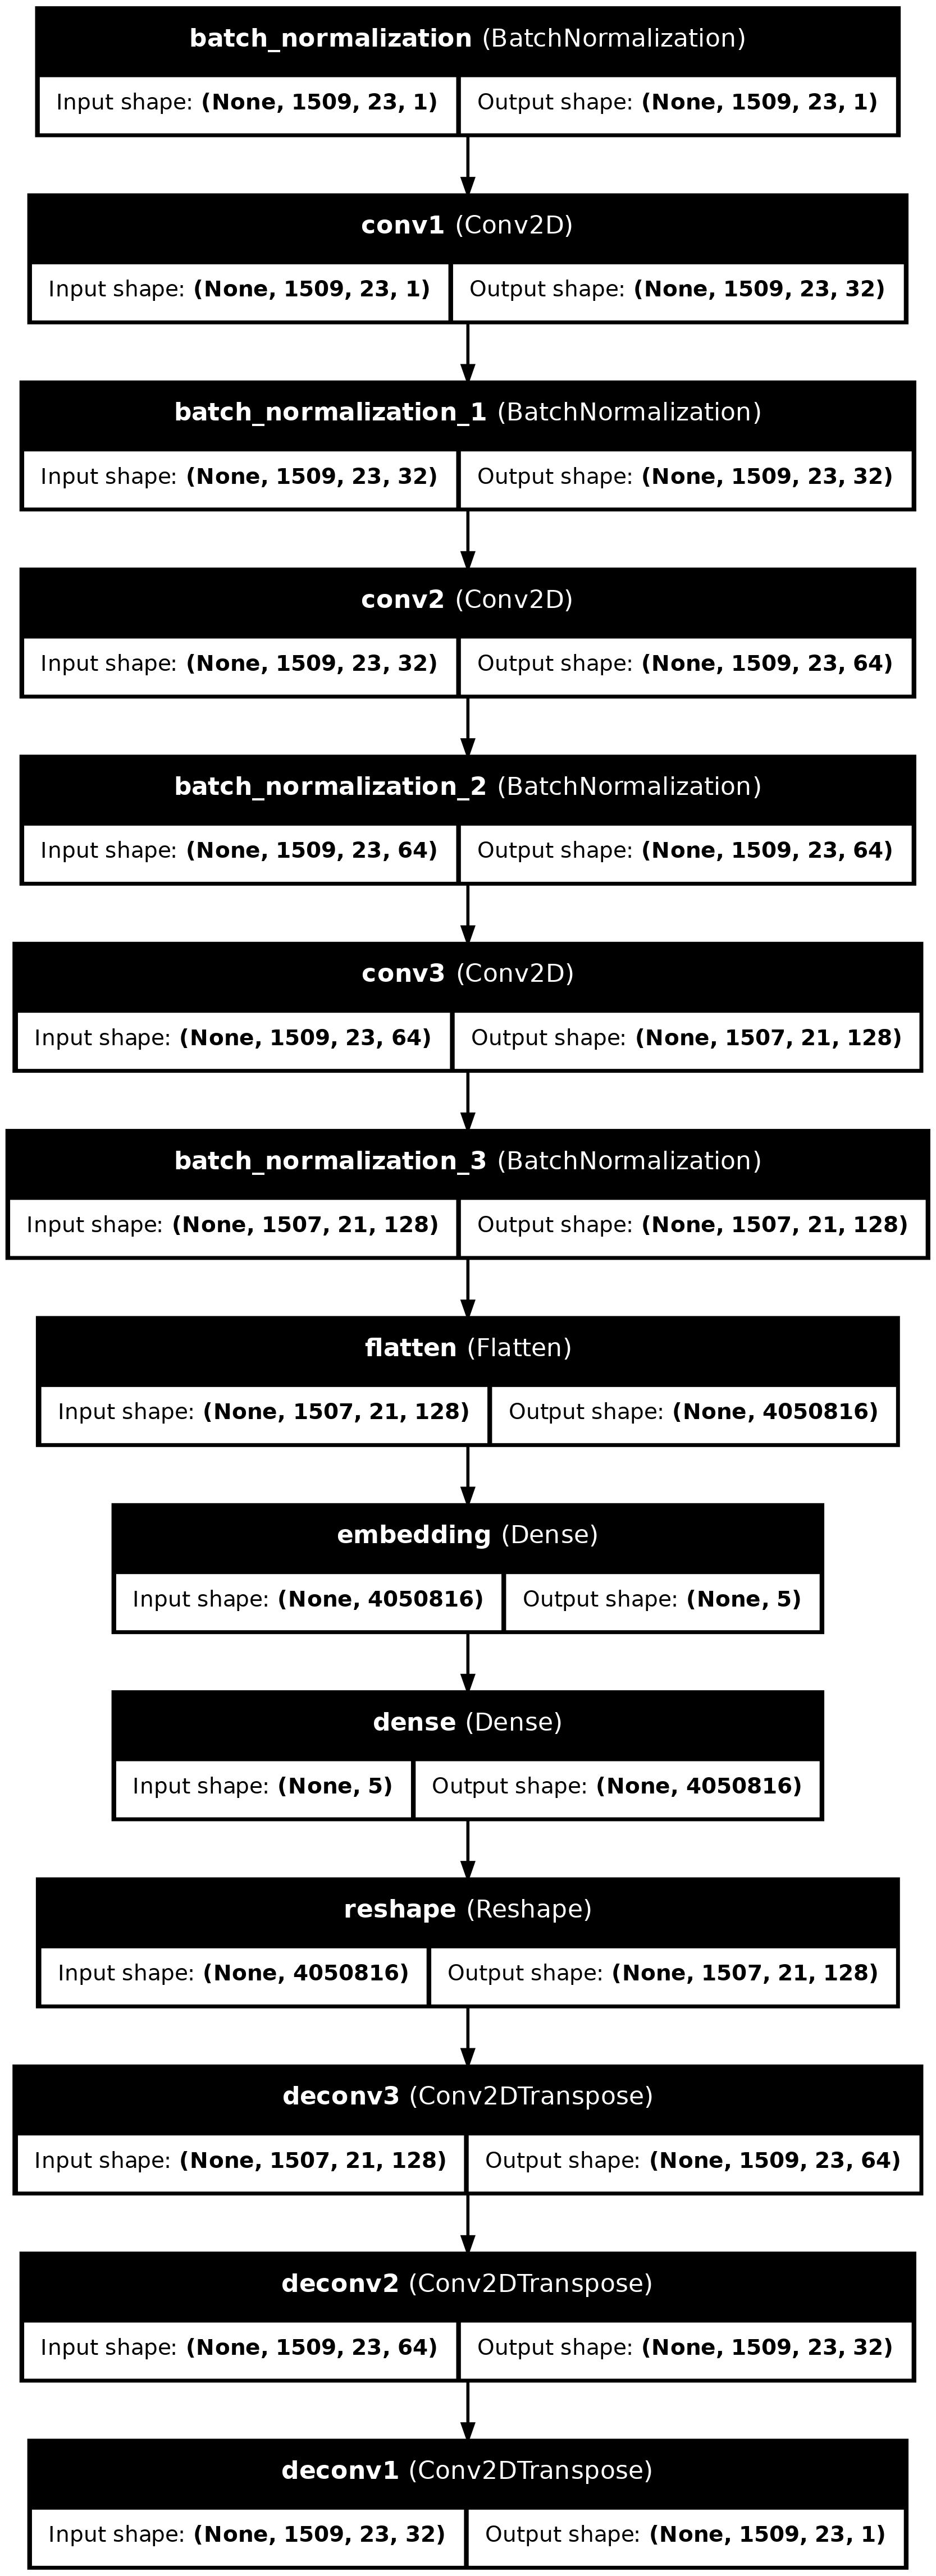

In [21]:
# plot the model
os.makedirs(f'{current_path}/images', exist_ok=True)
plot_model(model, f'{current_path}/images/CAE-model.png', show_shapes=True, show_layer_names=True)

In [22]:
# compile the model and callbacks
optimizer = 'adam'
model.compile(optimizer=optimizer, loss='mse')
from keras.callbacks import CSVLogger
csv_logger = CSVLogger(args['save_dir'] + '/%s-pretrain-log.csv' % 'data')

## Trainer

In [23]:
early_stopping = tf.keras.callbacks.EarlyStopping(monitor = 'loss', patience = 100, verbose = 1, mode = 'min', restore_best_weights = True)
model_checkpoint = tf.keras.callbacks.ModelCheckpoint(filepath = 'best_model.keras', monitor = 'loss', save_best_only = True)
#args['batch_size'] = 8
#args['epochs'] = 1000
#args['save_dir'] = 'results/temp'

# begin training
from time import time
t0 = time()

model.fit(x, x, 
    batch_size=8, #args['batch_size'], 
    epochs=args['epochs'], 
    verbose = 1, 
    callbacks=[early_stopping, model_checkpoint, csv_logger]
    ) 
print('Training time: ', time() - t0)
model.save(args['save_dir'] + '/%s-pretrain-model-%d.keras' % ('data', args['epochs']))

Epoch 1/1000


I0000 00:00:1749443578.159262  313231 service.cc:152] XLA service 0x7f6860027b40 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1749443578.159305  313231 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 3060, Compute Capability 8.6
2025-06-09 04:32:58.207460: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1749443578.548765  313231 cuda_dnn.cc:529] Loaded cuDNN version 90300


2/9 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 1.0126 

I0000 00:00:1749443587.615419  313231 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


9/9 ━━━━━━━━━━━━━━━━━━━━ 20s 991ms/step - loss: 1.1491
Epoch 2/1000
9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 418ms/step - loss: 1.0821
Epoch 3/1000
9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 413ms/step - loss: 0.9851
Epoch 4/1000
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 396ms/step - loss: 1.0280
Epoch 5/1000
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 410ms/step - loss: 1.0476
Epoch 6/1000
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - loss: 1.0814
Epoch 7/1000
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 401ms/step - loss: 1.0034
Epoch 8/1000
9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 417ms/step - loss: 0.9441
Epoch 9/1000
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 318ms/step - loss: 0.9755
Epoch 10/1000
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - loss: 1.1015
Epoch 11/1000
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - loss: 1.0436
Epoch 12/1000
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 406ms/step - loss: 0.9626
Epoch 13/1000
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - loss: 0.9788
Epoch 14/1000
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 412ms/step - loss: 1.0477
Epoch 15/1000
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 380ms/step - loss: 0.9446
Epoch

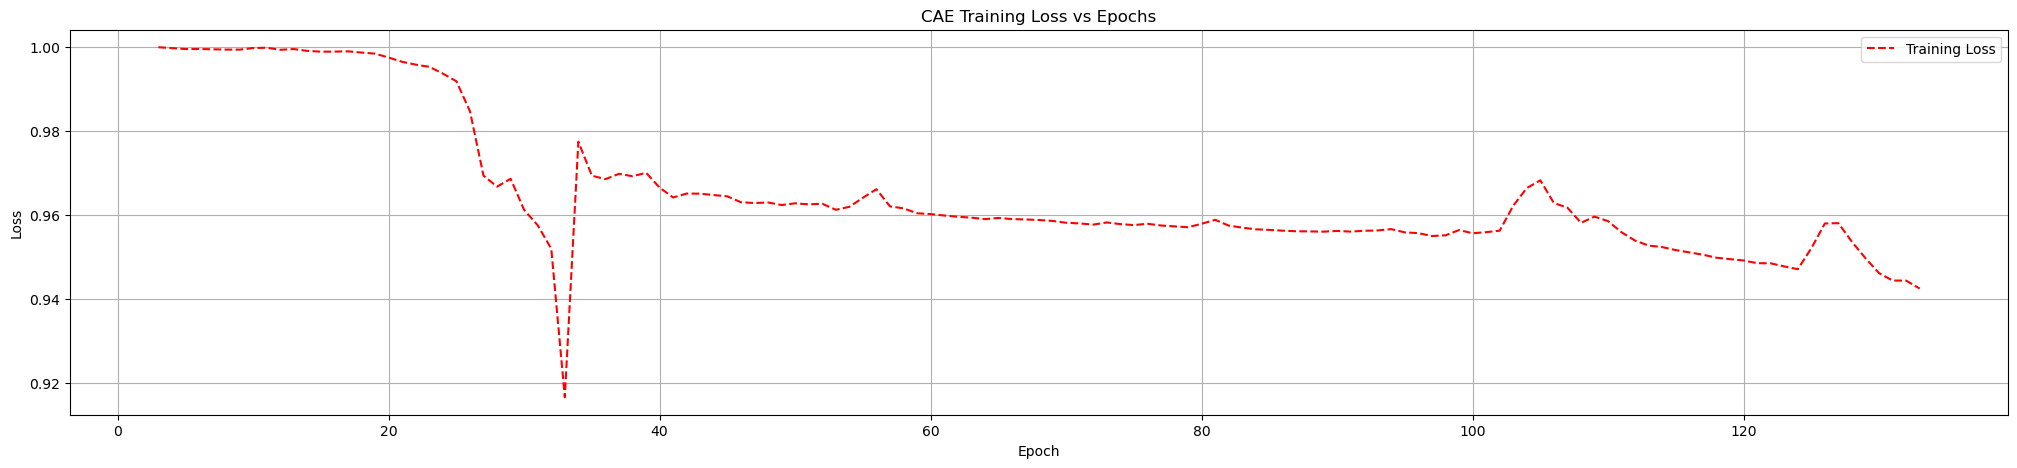

In [24]:
import matplotlib.pyplot as plt
training_loss = model.history.history['loss']
epoch_count = range(1, len(training_loss) + 1)
plt.figure(figsize = (25,5))
plt.plot(epoch_count[2:], training_loss[2:], "r--")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Training Loss"])
plt.title("CAE Training Loss vs Epochs")
plt.grid()
plt.savefig(f'{current_path}/images/CAE-clustering-training-loss.png')
plt.show()

In [25]:
model

<Sequential name=sequential, built=True>

In [26]:
features = model.predict(x)
features


3/3 ━━━━━━━━━━━━━━━━━━━━ 11s 416ms/step


array([[[[-3.74827683e-01],
         [-2.89411128e-01],
         [-4.41041470e-01],
         ...,
         [ 6.25102594e-03],
         [ 6.25102594e-03],
         [ 6.25102594e-03]],

        [[-4.15872335e-01],
         [-4.87184435e-01],
         [-4.37650472e-01],
         ...,
         [ 3.05960327e-02],
         [ 1.74622945e-02],
         [ 6.25102594e-03]],

        [[-7.55869567e-01],
         [-7.10325062e-01],
         [-3.96314174e-01],
         ...,
         [ 1.03259802e-01],
         [ 6.14286438e-02],
         [ 6.25102594e-03]],

        ...,

        [[ 4.79755737e-02],
         [ 5.70782050e-02],
         [ 1.20449334e-01],
         ...,
         [ 1.89209655e-01],
         [ 6.39927447e-01],
         [-4.17479724e-02]],

        [[ 3.92552465e-03],
         [ 4.06486019e-02],
         [ 7.18818456e-02],
         ...,
         [ 3.04202259e-01],
         [ 1.34592995e-01],
         [-1.17841773e-02]],

        [[ 1.81245804e-03],
         [ 7.67457932e-02],
         [

In [27]:
features.shape

(66, 1509, 23, 1)

## cluster

In [28]:
from sklearn.cluster import AgglomerativeClustering
Agg_Clustering = AgglomerativeClustering(n_clusters = n_clusters)
features = np.reshape(features, newshape = (features.shape[0], -1))
pred = Agg_Clustering.fit_predict(features)

In [29]:
pred

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 3, 4, 1, 3, 1, 3, 1, 1, 1, 1, 1, 1,
       1, 3, 4, 3, 2, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 2, 1])

In [30]:
indices = np.array(indices)
indices.shape

(66,)

In [31]:
clustered_data = np.vstack((indices, pred)).T

cluster_data = pd.Series(clustered_data[:, 1], index=clustered_data[:, 0])
cluster_data = cluster_data.astype(int)
cluster_data.to_csv(f'{current_path}/cae_cluster_Index_data.csv')
cluster_data

ARKK    0
ARKQ    0
ARKW    0
CIBR    0
CQQQ    0
       ..
XLK     3
XNTK    3
XSD     3
XSW     2
XT      1
Length: 66, dtype: int64

## CAE Cluster Analysis: Historical Price Series by Cluster

For each cluster identified by the CAE, the normalized price series of the ETFs belonging to that cluster are displayed.

In [32]:
close_prices = pd.DataFrame({
    ticker: df['adjClose']
    for ticker, df in index_dict.items()
})
close_prices.index = close_prices.index.tz_localize(None)
close_prices.dropna(inplace=True, how='any')
close_prices.to_excel(f'{current_path}/etf_close_prices.xlsx', index=True)
close_prices

,ARKK,ARKQ,ARKW,CIBR,CQQQ,CWEB,FDN,FTC,FTEC,FTXL,...,TLTE,TQQQ,USD,VGT,VV,XLK,XNTK,XSD,XSW,XT
date,,,,,,,,,,,,,,,,,,,,,
2018-01-02,36.133634,32.247813,41.379598,22.503973,61.906008,509.985282,111.07,59.363983,47.459949,29.450725,...,48.077599,11.655315,5.208040,156.413246,109.756618,60.083412,62.744553,69.745467,68.536574,33.627027
2018-01-03,36.283489,32.711363,41.806371,22.696397,62.279113,515.860900,112.64,60.087699,47.984472,30.007875,...,48.369600,11.996567,5.338779,158.043136,110.458762,60.584571,63.616921,70.800603,69.117810,33.898590
2018-01-04,36.405245,32.830835,41.797662,22.811852,62.868226,527.153103,112.92,60.328938,48.256100,30.287404,...,48.424844,12.066895,5.354208,158.951753,110.920933,60.890835,63.800192,71.303971,70.024144,34.029689
2018-01-05,36.995297,33.241818,42.398628,22.840715,63.329699,546.359030,114.01,60.792116,48.724424,30.452450,...,48.661601,12.431324,5.394404,160.647214,111.631964,61.531205,64.547936,71.536295,70.162064,34.310617
2018-01-08,36.742418,33.652801,42.546693,23.023518,63.712622,559.560809,114.78,61.129850,48.996052,30.528772,...,48.764196,12.569583,5.498345,161.415323,111.880825,61.763223,65.024440,72.165504,70.831963,34.348074
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-24,60.960000,81.350000,115.110000,65.045671,40.530000,33.920000,252.18,142.224654,191.377526,90.320615,...,51.715100,88.164953,70.551191,643.636476,275.989039,240.116373,209.960519,257.480760,195.032110,61.090441
2024-12-26,60.960000,82.200000,114.480000,65.295654,40.950000,34.000000,251.37,141.914753,191.747020,90.840388,...,51.648300,87.975544,70.860845,644.755062,276.068767,240.276098,209.968415,259.578892,197.081502,61.150431
2024-12-27,59.270000,80.390000,111.680000,64.535705,40.660000,32.950000,248.15,140.525196,188.831019,89.500972,...,51.418800,84.396708,68.663300,634.697774,273.118825,237.081600,206.554046,255.972103,193.022707,60.670507


In [33]:

from keras import Model, Input

# Rebuild the encoder from the loaded Sequential model up to the 'embedding' layer
encoder_input = Input(shape=x.shape[1:])
x_enc = encoder_input
for layer in model.layers:
    x_enc = layer(x_enc)
    if layer.name == 'embedding':
        break
encoder = Model(encoder_input, x_enc)
print("Encoder model successfully rebuilt from the loaded CAE.")
latent_features = encoder.predict(x)

Encoder model successfully rebuilt from the loaded CAE.
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 171ms/step


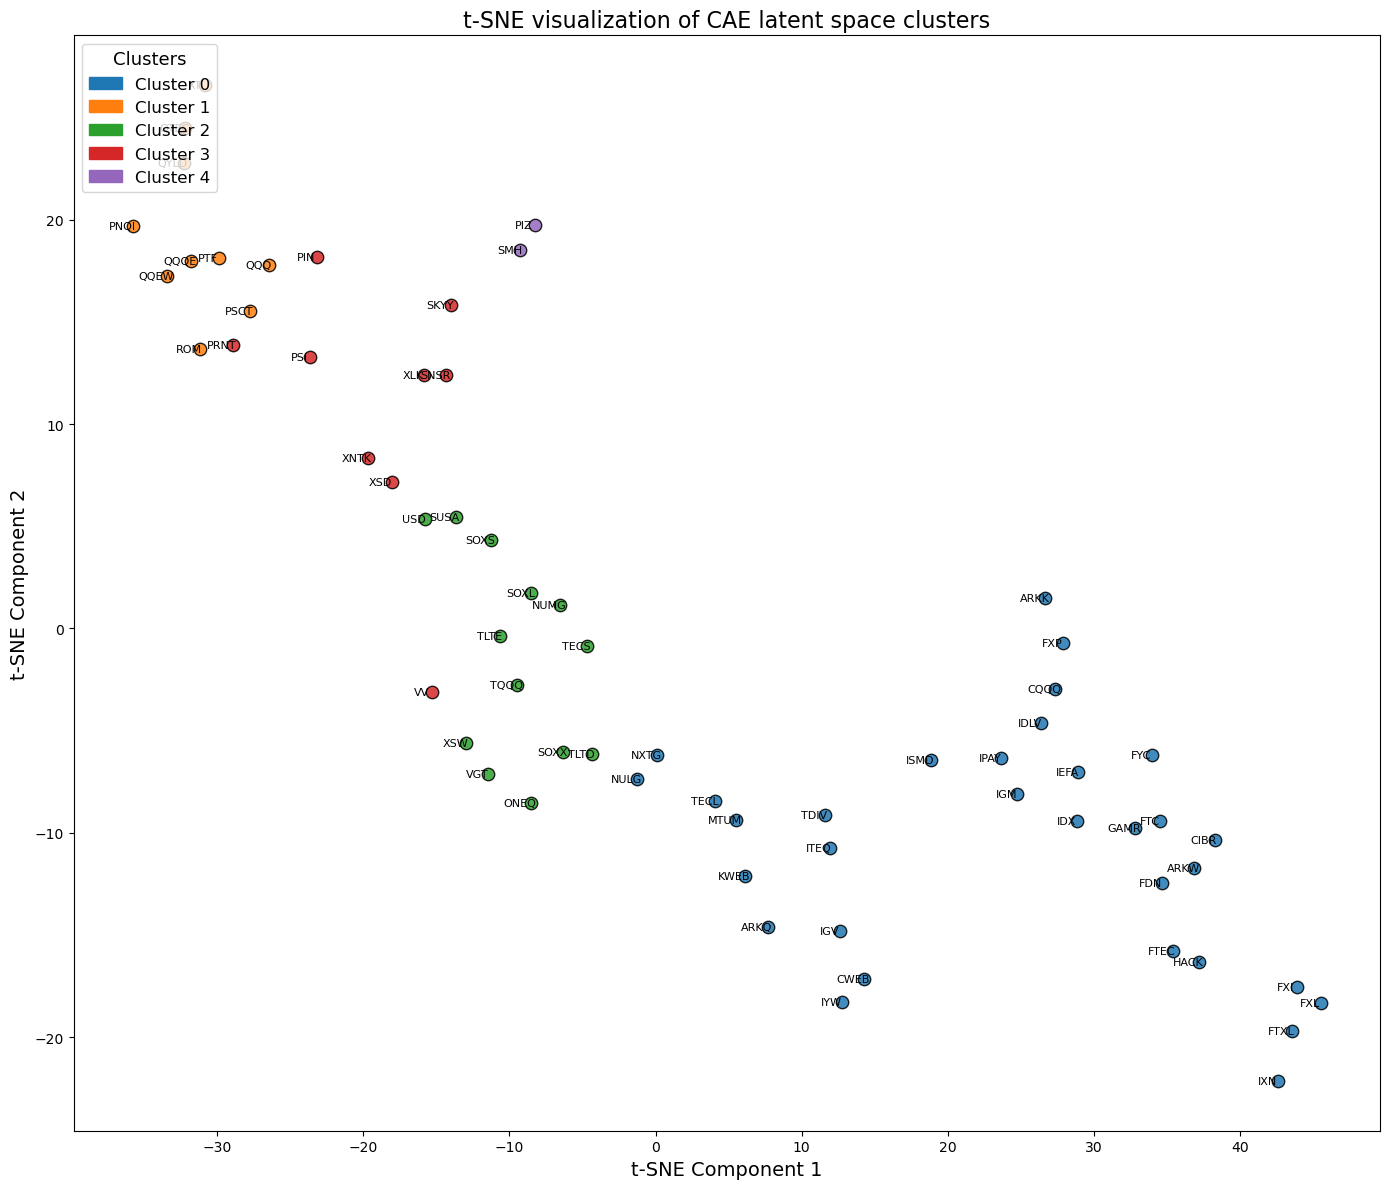

In [34]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Run t-SNE on the latent features
latent_reshaped = latent_features.reshape(latent_features.shape[0], -1)
tsne = TSNE(n_components=2, random_state=42, perplexity=5)
tsne_results = tsne.fit_transform(latent_reshaped)

# Prepare cluster labels and ETF tickers
clusters = pred
tickers = indices

# Create a discrete color map
unique_clusters = sorted(set(clusters))
colors = plt.cm.tab10.colors if len(unique_clusters) <= 10 else plt.cm.tab20.colors
cluster_color_map = {cl: colors[i % len(colors)] for i, cl in enumerate(unique_clusters)}

plt.figure(figsize=(14, 12))
for i, (x, y) in enumerate(tsne_results):
    cl = clusters[i]
    plt.scatter(x, y, color=cluster_color_map[cl], s=80, edgecolor='k', alpha=0.85)
    plt.text(x - 0.75, y, str(tickers[i]), fontsize=8, ha='center', va='center')

# Create legend
handles = [mpatches.Patch(color=cluster_color_map[cl], label=f'Cluster {cl}') for cl in unique_clusters]
plt.legend(handles=handles, title='Clusters', loc='upper left', fontsize=12, title_fontsize=13, frameon=True)

plt.title('t-SNE visualization of CAE latent space clusters', fontsize=16)
plt.xlabel('t-SNE Component 1', fontsize=14)
plt.ylabel('t-SNE Component 2', fontsize=14)
plt.tight_layout()
plt.savefig(f'{current_path}/tsne_cae_latent_clusters.png', dpi=300, bbox_inches='tight')
plt.show()

# Pairs Selection



In [35]:
os.chdir('/mnt/d/GitHub/WQU-Capstone/notebooks/classes')

os.getcwd()

'/mnt/d/GitHub/WQU-Capstone/notebooks/classes'

In [36]:
%load_ext autoreload
%aimport class_SeriesAnalyser, class_Trader, class_DataProcessor, class_ForecastingTrader
%autoreload 1

I0000 00:00:1749443773.495982  313145 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9706 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:01:00.0, compute capability: 8.6


In [37]:
series_analyser = class_SeriesAnalyser.SeriesAnalyser()
trader = class_Trader.Trader()
data_processor = class_DataProcessor.DataProcessor()

In [38]:
# split data in training and test
df_prices_train, df_prices_test = data_processor.split_data(close_prices,
                                                            ('02-01-2018',
                                                             '31-12-2023'),
                                                            ('01-01-2024',
                                                             '31-12-2024'),
                                                            remove_nan=True)
train_val_split = '01-01-2023'

Total of 66 tickers
Total of 66 tickers after removing tickers with Nan values


In [39]:
df_prices_train

,ARKK,ARKQ,ARKW,CIBR,CQQQ,CWEB,FDN,FTC,FTEC,FTXL,...,TLTE,TQQQ,USD,VGT,VV,XLK,XNTK,XSD,XSW,XT
date,,,,,,,,,,,,,,,,,,,,,
2018-02-01,38.166034,34.230088,43.522175,23.398744,61.915826,563.233070,121.80,63.407142,50.307359,30.748198,...,50.547771,13.803525,5.548692,165.836634,115.107131,63.582245,67.040418,71.100688,73.413044,35.471784
2018-02-02,37.276274,33.251376,42.686047,23.004275,60.413587,529.356460,119.73,62.017608,48.930486,30.042220,...,49.285063,12.960384,5.257575,161.171776,112.609633,61.698258,65.544929,68.303125,72.102801,34.760101
2018-02-05,35.955682,32.066216,40.961534,22.330792,58.577517,495.663463,115.56,60.078050,46.972892,28.716126,...,48.077599,11.464310,4.735431,154.867661,107.987927,59.118216,63.023124,65.147397,69.945332,33.336735
2018-02-06,36.798613,32.583290,41.893468,22.542458,59.088082,507.139279,118.08,60.685971,48.218634,29.393484,...,49.127225,12.348209,5.114249,158.783144,109.934376,60.816589,64.437974,67.122147,70.132510,34.020325
2018-02-07,37.313737,32.668354,42.111210,22.330792,57.654572,484.738486,118.15,60.589475,47.628546,29.201725,...,47.572516,11.859906,5.030608,157.003379,109.401103,60.037008,64.049440,65.031235,70.989586,33.748762
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-22,53.010000,57.840000,76.470000,53.853912,34.535629,29.166545,187.70,109.049714,142.581283,80.500185,...,48.233572,49.509907,26.570021,479.861759,214.199607,190.410512,162.694938,224.973598,151.698506,59.087093
2023-12-26,53.790000,58.820000,77.200000,54.123082,34.505711,29.539984,188.13,109.528002,143.256741,82.081545,...,48.359051,50.414557,27.358390,482.233235,215.114443,191.203683,164.063642,228.612819,152.992223,59.633552
2023-12-27,54.260000,58.840000,78.290000,53.993481,34.405983,29.501683,188.10,109.647574,143.346140,82.151165,...,48.785930,50.680052,27.428245,482.699592,215.458736,191.193768,164.445474,228.383498,153.602077,59.802457


In [40]:
df_prices_test

,ARKK,ARKQ,ARKW,CIBR,CQQQ,CWEB,FDN,FTC,FTEC,FTXL,...,TLTE,TQQQ,USD,VGT,VV,XLK,XNTK,XSD,XSW,XT
date,,,,,,,,,,,,,,,,,,,,,
2024-01-02,50.50,56.43,72.92,52.308677,34.804893,29.674039,182.18,107.664671,138.856330,78.461324,...,48.742046,47.326948,25.407427,467.637246,213.550368,185.839867,158.803078,217.525660,146.071290,58.361793
2024-01-03,48.52,54.42,70.50,51.570953,34.804893,30.593274,179.65,105.811304,137.207417,76.571649,...,48.513368,45.812643,24.449409,461.376152,211.819065,183.946172,156.958602,210.905271,141.796520,57.249005
2024-01-04,48.91,54.63,71.03,51.301783,34.216501,29.961300,179.04,106.080341,136.184296,75.726268,...,48.330117,45.045658,24.359595,458.597853,211.120641,182.597782,156.230464,207.256080,141.956325,56.891322
2024-01-05,48.90,54.41,71.02,51.222029,33.837536,29.233573,179.96,106.349378,136.263762,76.163877,...,48.605572,45.212821,24.853573,458.707001,211.514119,182.548209,156.671805,207.784515,141.568899,56.811838
2024-01-08,50.28,55.46,73.71,52.288739,33.378790,28.601599,184.64,107.654707,139.720519,78.332031,...,48.682827,47.936603,26.979174,470.385777,214.494715,187.128769,160.464948,214.355052,145.661791,57.835206
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-24,60.96,81.35,115.11,65.045671,40.530000,33.920000,252.18,142.224654,191.377526,90.320615,...,51.715100,88.164953,70.551191,643.636476,275.989039,240.116373,209.960519,257.480760,195.032110,61.090441
2024-12-26,60.96,82.20,114.48,65.295654,40.950000,34.000000,251.37,141.914753,191.747020,90.840388,...,51.648300,87.975544,70.860845,644.755062,276.068767,240.276098,209.968415,259.578892,197.081502,61.150431
2024-12-27,59.27,80.39,111.68,64.535705,40.660000,32.950000,248.15,140.525196,188.831019,89.500972,...,51.418800,84.396708,68.663300,634.697774,273.118825,237.081600,206.554046,255.972103,193.022707,60.670507


In [41]:
cluster_data

ARKK    0
ARKQ    0
ARKW    0
CIBR    0
CQQQ    0
       ..
XLK     3
XNTK    3
XSD     3
XSW     2
XT      1
Length: 66, dtype: int64

In [42]:
subsample = 2500
min_half_life = 21 # avg. number of points in a month
max_half_life = 252 # avg. number of points in a year

In [43]:
pairs_unsupervised, unique_tickers = series_analyser.get_candidate_pairs(clustered_series=cluster_data,
                                                            pricing_df_train=df_prices_train,
                                                            pricing_df_test=df_prices_test,
                                                            min_half_life=min_half_life,
                                                            max_half_life=max_half_life,
                                                            min_zero_crosings=12,
                                                            p_value_threshold=0.10,
                                                            hurst_threshold=0.5,
                                                            subsample=subsample
                                                            )

Cluster 5/5Found 103 pairs
The pairs contain 53 unique tickers
Pairs Selection failed stage:  {'cointegration': 543, 'hurst_exponent': 10, 'None': 103}


In [44]:
pairs_unsupervised

[('ARKK',
  'ARKW',
  {'t_statistic': np.float64(-2.5759441528439395),
   'critical_val': {'1%': np.float64(-3.434827656046504),
    '5%': np.float64(-2.86351758903648),
    '10%': np.float64(-2.5678228503262757)},
   'p_value': np.float64(0.09807174179088884),
   'coint_coef': np.float64(0.7962170095206533),
   'zero_cross': 51,
   'half_life': 81,
   'hurst_exponent': np.float64(0.3688753269178084),
   'spread': date
   2018-02-01    3.512938
   2018-02-02    3.288917
   2018-02-05    3.341412
   2018-02-06    3.442321
   2018-02-07    3.784076
                   ...   
   2023-12-22   -7.876715
   2023-12-26   -7.677953
   2023-12-27   -8.075830
   2023-12-28   -7.964927
   2023-12-29   -8.062871
   Length: 1488, dtype: float64,
   'Y_train': date
   2018-02-01    38.166034
   2018-02-02    37.276274
   2018-02-05    35.955682
   2018-02-06    36.798613
   2018-02-07    37.313737
                   ...    
   2023-12-22    53.010000
   2023-12-26    53.790000
   2023-12-27    54.260

In [45]:
pairs = pairs_unsupervised.copy()
pairs

[('ARKK',
  'ARKW',
  {'t_statistic': np.float64(-2.5759441528439395),
   'critical_val': {'1%': np.float64(-3.434827656046504),
    '5%': np.float64(-2.86351758903648),
    '10%': np.float64(-2.5678228503262757)},
   'p_value': np.float64(0.09807174179088884),
   'coint_coef': np.float64(0.7962170095206533),
   'zero_cross': 51,
   'half_life': 81,
   'hurst_exponent': np.float64(0.3688753269178084),
   'spread': date
   2018-02-01    3.512938
   2018-02-02    3.288917
   2018-02-05    3.341412
   2018-02-06    3.442321
   2018-02-07    3.784076
                   ...   
   2023-12-22   -7.876715
   2023-12-26   -7.677953
   2023-12-27   -8.075830
   2023-12-28   -7.964927
   2023-12-29   -8.062871
   Length: 1488, dtype: float64,
   'Y_train': date
   2018-02-01    38.166034
   2018-02-02    37.276274
   2018-02-05    35.955682
   2018-02-06    36.798613
   2018-02-07    37.313737
                   ...    
   2023-12-22    53.010000
   2023-12-26    53.790000
   2023-12-27    54.260

In [46]:
from collections import Counter

# Store all pair names in a list
pair_names = [(pair[0], pair[1]) for pair in pairs]

# Find duplicates
duplicates = [item for item, count in Counter(pair_names).items() if count > 1]
print("Duplicate pairs:", duplicates)


Duplicate pairs: []


### Ploting spreads

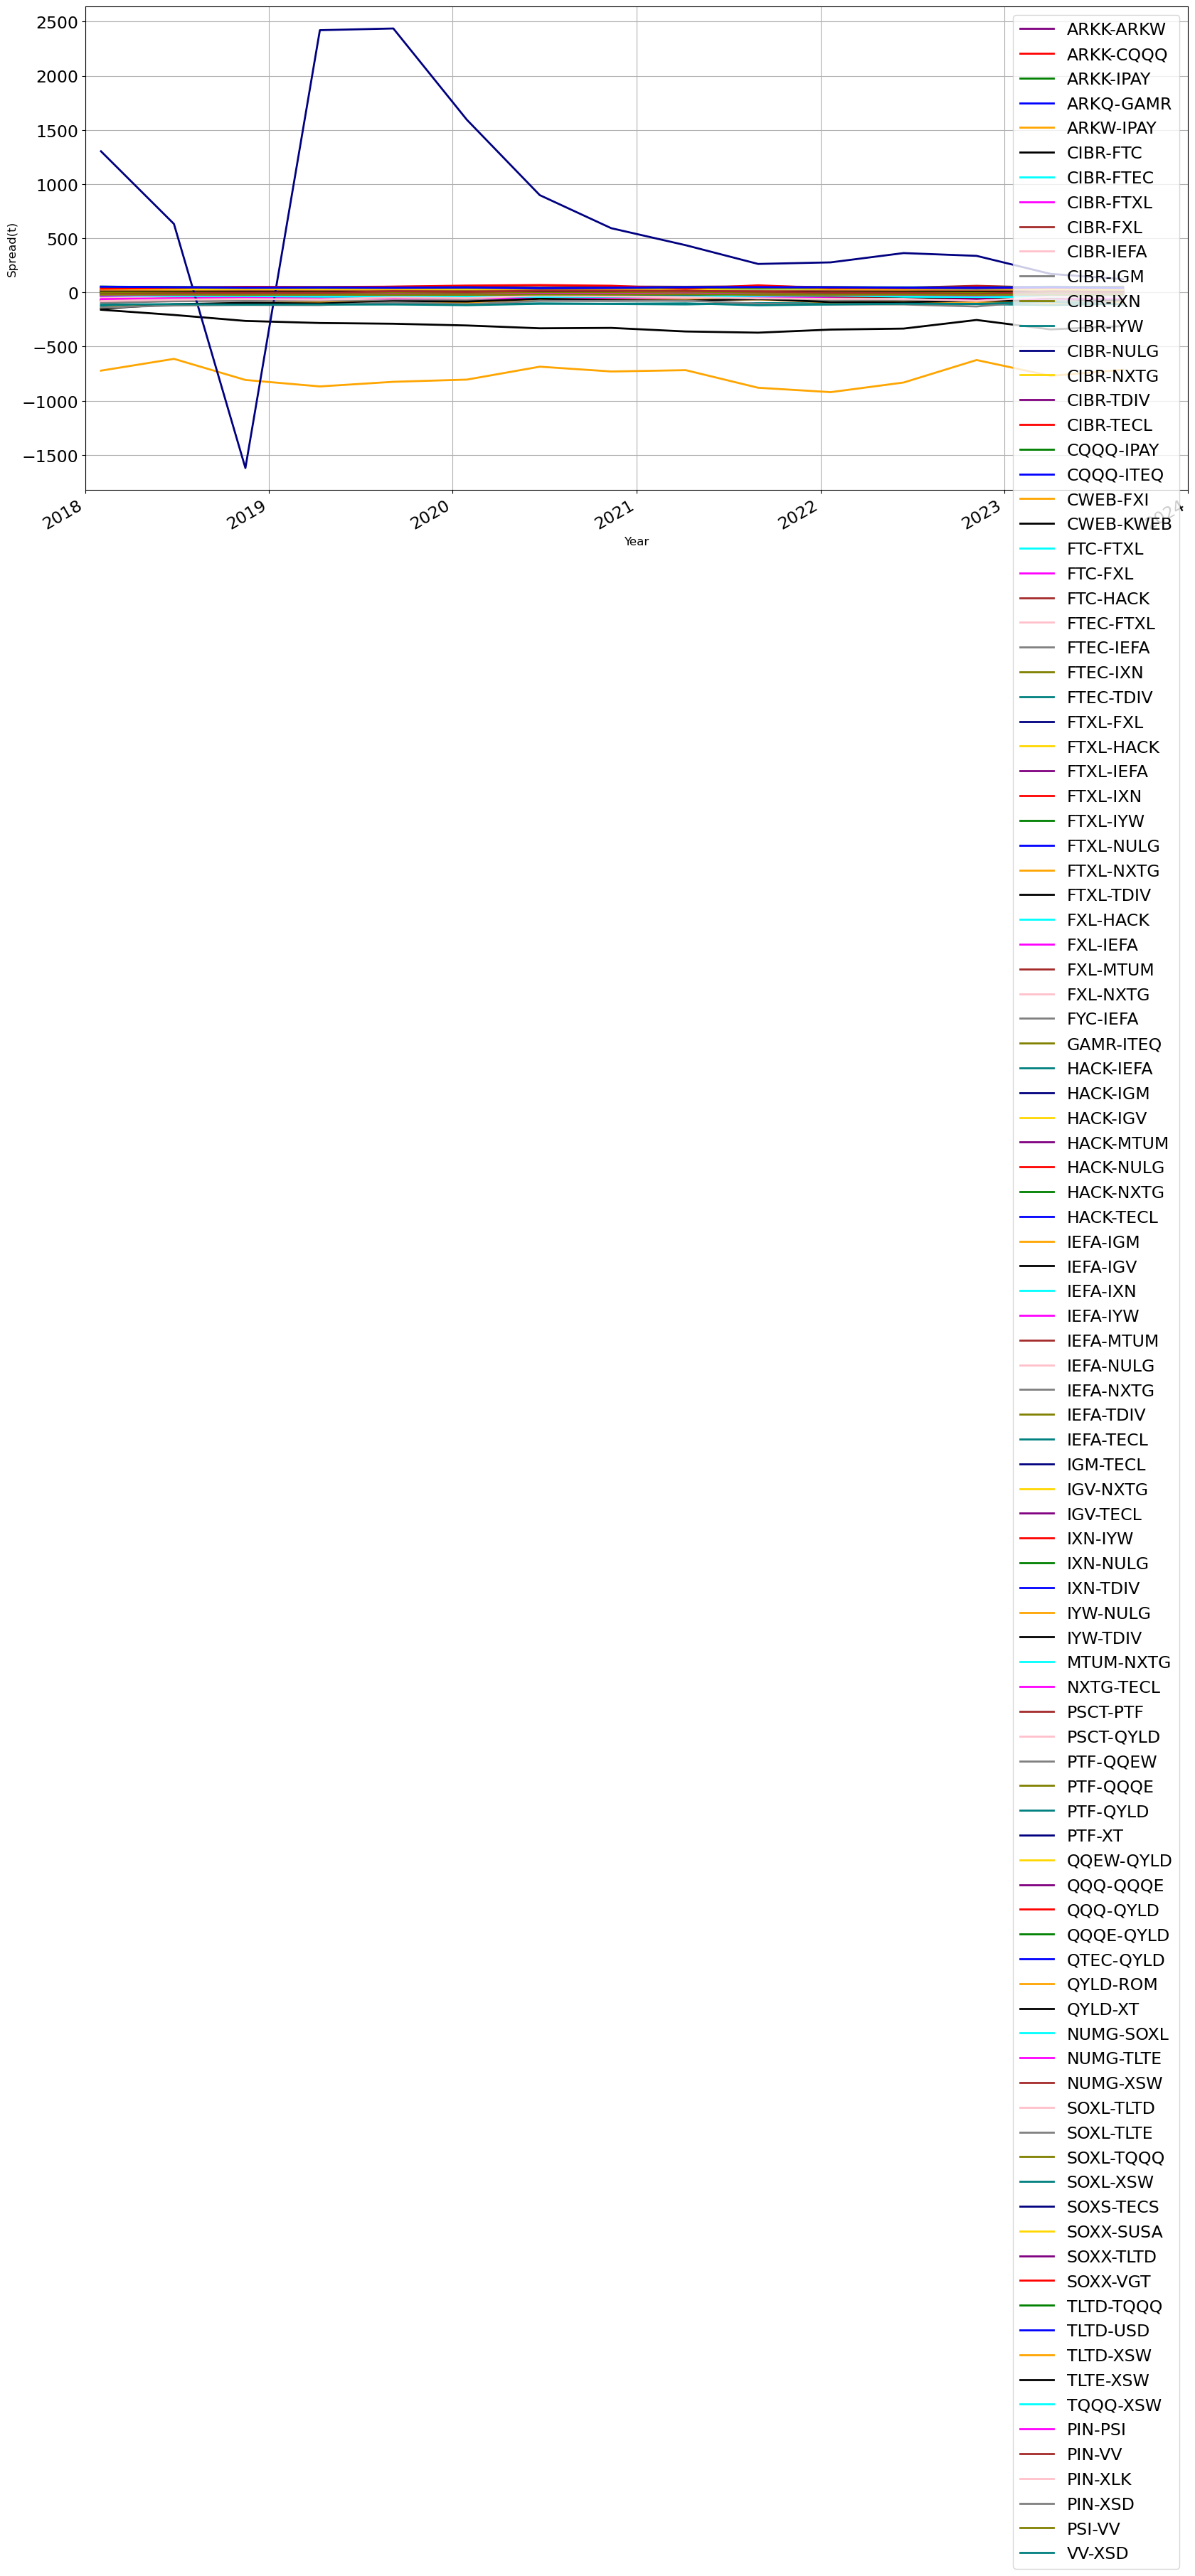

In [47]:
#markers= ["o","s","+","x","<"]
plt.rcParams.update({'font.size': 17})
colors = [
    'purple', 'red', 'green', 'blue', 'orange',
    'black', 'cyan', 'magenta', 'brown', 'pink',
    'gray', 'olive', 'teal', 'navy', 'gold'
]
for i in range(len(pairs)):
    pairs[i][2]['spread'][::100].plot(figsize=(20,10), grid=True, label='{}-{}'.format(pairs[i][0],pairs[i][1]), c=colors[i % len(colors)], linewidth=2)
plt.ylabel('Spread(t)',size=12)
plt.xlabel('Year',size=12)
plt.xlim(('2018', '2024'))
plt.legend()
#plt.savefig('spreads.png', bbox_inches='tight', pad_inches=0.05)

### Droping highest spread

In [56]:
# list only the names of the top 3 pairs with highest spread
top = 3
pairs_sorted = sorted(pairs, key=lambda x: np.abs(x[2]['spread']).max(), reverse=True)
top_pairs_names = [(p[0], p[1]) for p in pairs_sorted[:top]]
print(f"Top {top} pairs with highest spread:", top_pairs_names)
# Save the top spread pairs to a list
top_spread_pairs = pairs_sorted[:top]

Top 3 pairs with highest spread: [('CWEB', 'FXI'), ('CWEB', 'KWEB'), ('TLTE', 'XSW')]


In [57]:
# droping the highest spread pairs from the list
top_names = set((p[0], p[1]) for p in top_spread_pairs)
pairs = [pair for pair in pairs if (pair[0], pair[1]) not in top_names]

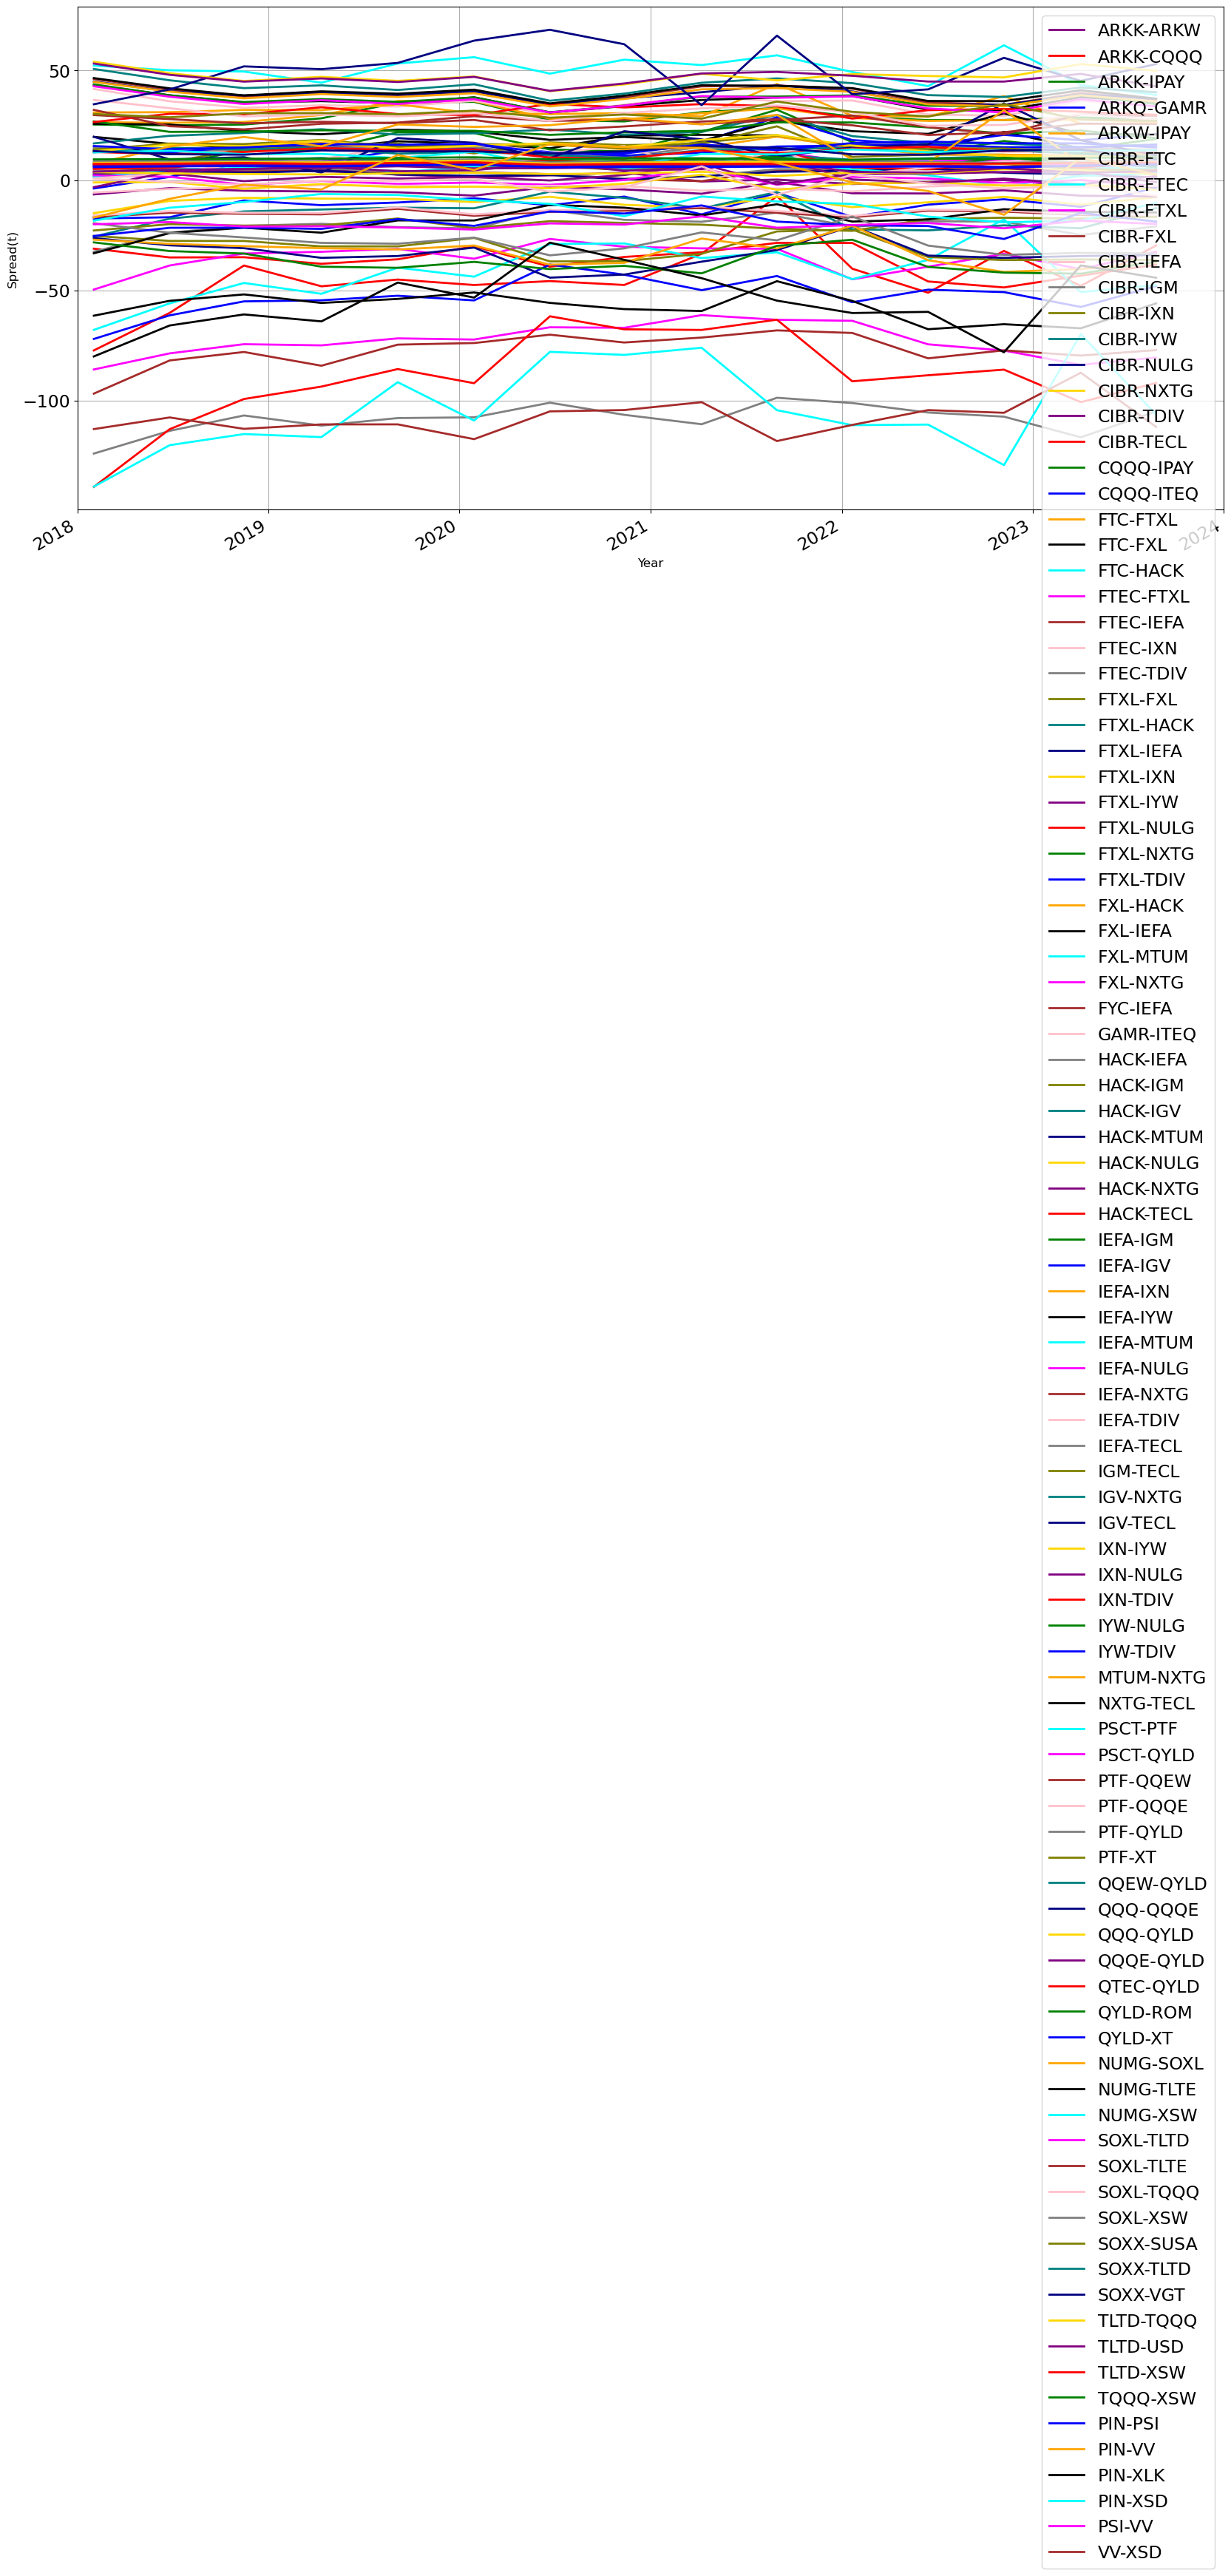

In [58]:
#markers= ["o","s","+","x","<"]
plt.rcParams.update({'font.size': 17})
colors = [
    'purple', 'red', 'green', 'blue', 'orange',
    'black', 'cyan', 'magenta', 'brown', 'pink',
    'gray', 'olive', 'teal', 'navy', 'gold'
]
for i in range(len(pairs)):
    pairs[i][2]['spread'][::100].plot(figsize=(20,10), grid=True, label='{}-{}'.format(pairs[i][0],pairs[i][1]), c=colors[i % len(colors)], linewidth=2)
plt.ylabel('Spread(t)',size=12)
plt.xlabel('Year',size=12)
plt.xlim(('2018', '2024'))
plt.legend()
#plt.savefig('spreads.png', bbox_inches='tight', pad_inches=0.05)

In [59]:
len(pairs)

99

### Saving

In [60]:
import pickle
with open(f'{current_path}/CAE_selected_pairs.pickle', 'wb') as f:
   pickle.dump(pairs, f)